In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Data frames proyecto logistica y op/cuentas_pagar.csv")
df.head()
df.tail(40) #(128,12) mediante el metodo df.shape
df["fecha_compra"] = pd.to_datetime(df["fecha_compra"], errors = "coerce") #Se convierte a fecha las fechas de compra
df["fecha_pago_acordado"] = pd.to_datetime(df["fecha_pago_acordado"], errors = "coerce") #Se convierte a fecha las fechas de pago
df["fecha_pago_real"] = pd.to_datetime(df["fecha_pago_real"], errors = "coerce") #Se convierte a fecha las fechas de pago
df["id_duplicado"] = df["orden_compra_id"].duplicated(keep = False) #se crea una columna para identificar duplicados en las orden de compra, se identifican dos duplicados. OC-001,  OC-025 (ambos con mismos datos)
df[df["id_duplicado"]== True] #verificacion visual de los duplicados
df = df.drop_duplicates(subset = "orden_compra_id", keep = "first") #Se borran los 2 duplicados encontrados
df["orden_compra_id"].value_counts() #verificacion de que haya solo 1 registro de compra por producto
df.shape #verificacion de que se hayan borrado los dos registros (126, 13)
df = df.drop(labels = "id_duplicado", axis = 1) #borramos la columna id_duplicado, puesto que ya la ocupamos para saber si el id estaba duplicado o no
df.shape #corroboramos que efectivamente se borró la columna
sintaxis_orden_id = r"^OC-\d+$" #creamos un regex para evaluar nombres inconsistentes
df[~df["orden_compra_id"].str.match(sintaxis_orden_id, na = False)] #hacemos uso de match para saber que ordenes no cumplen con el patron general de los id (PENDIENTE) <- (RESUELTO)
sintaxis_proveedor_id = r"^PR\d+"
df[~df["proveedor_id"].str.match(sintaxis_proveedor_id, na = False)] #confirmamos que todos los id de los proveedores tengan una sintaxis valida
df[df["proveedor_nombre"].isna()] #hay 1 registro (122) en donde no esta definido el nombre del proveedor (NaN), sin embargo esta el id del proveedor (PENDIENTE) <- (RESUELTO)
df[df["proveedor_id"]== "PR011"] #solo hay 1 registro con el id PR011, por lo que no se puede acceder al nombre del proveedor para completarlo (PENDIENTE) <- (RESUELTO)
df.groupby("proveedor_id")["proveedor_nombre"].nunique() #se comprueba que haya consistencias entre el id del proveedor y el nombre (un id -> un nombre)
df[df["proveedor_nombre"].isna()] #solo hay un proveedor sin nombre (RESUELTO)
df["proveedor_nombre"].value_counts() #hay un solo registro con nombre invalido (RESUELTO)
df["categoria"].value_counts(dropna = False) #comprobamos que las categorias sean consistentes
df["fecha_compra"].dt.year #comprobamos que solo haya registros del año 2023
df["fecha_compra"].isna().sum() #comprobamos que solo haya un registro NaT en fecha_compra (PENDIENTE) <- (RESUELTO), SE DEJARÁ ASI NOMAS
df["fecha_pago_acordado"].isna().sum() #comprobamos que solo haya un registro NaT en fecha_pago_acordado (ahora no aparece)
df["fecha_pago_acordado"].dt.year #comprobamos que solo haya registros del año 2023 (hay pagos comprometidos a 2024 tambien)
df["fecha_pago_real"].dt.year #comprobamos que solo haya registros del año 2023
df["fecha_pago_real"].isna().sum() #corroboramos los pagos que estan pendientes (son 39)
df["corroboracion_fechas"] = (df["fecha_pago_real"] - df["fecha_compra"]).dt.days #se busca inconsistencias en las fechas (si o si la fecha de pago tiene que ser posterior a la compra)
df[df["corroboracion_fechas"]< 0] #se encuentra un registro en donde aparece que la fecha de pago es anterior a la fecha de compra (PENDIENTE) <- (ARREGLADO)
df.loc[df["fecha_pago_acordado"].isna(), "fecha_pago_acordado"] = (df["fecha_compra"] + pd.to_timedelta(df["condicion_pago_dias"], unit = "D")) #ya que tenemos la condicion de pago, rellenamos el campo que nos faltaba en fecha_pago_acordado
df.iloc[121, :] #se corrobora que se haya llenado
df[df["condicion_pago_dias"].isna()] #corroboramos que haya condicion de pago en todas las transacciones (todas estan llenas)
df[df["condicion_pago_dias"] < 0] #corroboramos que no haya dias negativos
df[df["monto_compra"] != df["monto_pagado"]] #buscamos incoherencias entre el monto comprado y el monto pagado, en caso de que existieran, tambien aprovechamos de verificar que el estado este correcto (no hay, excepto los NaN)
df[df["monto_compra"] == df["monto_pagado"]] #se identifica un registro en donde el pago es negativo (126) PENDIENTE
df[df["estado"].isna()] #verificamos que todos los estados esten completos (lo estan)
df.value_counts("estado") #verificamos que no haya ningun valor extraño en la columna "estado" (no hay)
df[df["moneda"].isna()] #en el campo "moneda estan todos los registros completos (no hay NaN)"
df.value_counts("moneda") #solo hay registros que indican que las transacciones se realizaron en CLP
df[df["monto_compra"] < 0] #corroboramos que no haya un monto de compra negativo (si lo hay), como se mencionò mas arriba
df[df["monto_compra"].isna()] #no hay valores NaN en la columna monto_compra
df[df["monto_pagado"] < 0] #hay un solo registro en donde el monto pagado es negativo
df[df["monto_pagado"].isna()] #los registros que estan con NaN corresponden a las cuentas por pagar
df[df["fecha_compra"] + pd.to_timedelta(df["condicion_pago_dias"], unit = "D") != df["fecha_pago_acordado"]] #hay inconsistencias (PENDIENTE, registro 110, 124)





def estado_pago(fila):
  if fila["fecha_compra"] + pd.to_timedelta(fila["condicion_pago_dias"], unit = "D") == fila["fecha_pago_acordado"] and fila["fecha_pago_real"] == fila["fecha_pago_acordado"]:
    return "Pagado a tiempo"
  elif fila["fecha_compra"] + pd.to_timedelta(fila["condicion_pago_dias"], unit = "D") == fila["fecha_pago_acordado"] and fila["fecha_pago_real"] > fila["fecha_pago_acordado"]:
    return "Pagado con retraso"
  elif fila["fecha_compra"] + pd.to_timedelta(fila["condicion_pago_dias"], unit = "D") == fila["fecha_pago_acordado"] and fila["fecha_pago_real"] < fila["fecha_pago_acordado"]:
    return "Pagado con adelanto"
  elif pd.isna(fila["fecha_compra"]) and fila["monto_pagado"] != 0 and fila["fecha_pago_real"] == fila["fecha_pago_acordado"]:
    return "Pagado a tiempo"
  else:
    return "Pago pendiente"



df.loc[df["orden_compra_id"].isna(), "orden_compra_id"] = "ID_DESCONOCIDO"
df.loc[df["orden_compra_id"] == "OC-INVALID", "orden_compra_id"] = "ID_DESCONOCIDO"
df.loc[df["proveedor_nombre"].isna(), "proveedor_nombre"] ="NOMBRE_DESCONOCIDO"
df.loc[df["proveedor_nombre"] == "Proveedor Invalido", "proveedor_nombre"] = "NOMBRE_DESCONOCIDO"
df.loc[df["orden_compra_id"] == "OC-998", "fecha_compra"] = "2023-01-01"
df.loc[df["orden_compra_id"] == "OC-998", "fecha_pago_acordado"] = "2023-04-01"
df.loc[df["orden_compra_id"] == "OC-998", "fecha_pago_real"] = "2023-04-01"
df.loc[df["proveedor_id"]== "PR012", "categoria"] = "CATEGORIA_DESCONOCIDA"
df.loc[df["orden_compra_id"] == "OC-997", "monto_compra"] = 120000
df.loc[df["orden_compra_id"] == "OC-997", "monto_pagado"] = 120000
df["corroboracion_fechas"] = (df["fecha_pago_real"] - df["fecha_compra"]).dt.days #La volvemos a correr para arreglar incoherencias luego de arreglar las inconsistencias encontradas

# Ver los valores exactos de OC-111
fila = df.loc[df["orden_compra_id"] == "OC-111"].iloc[0]
#Se identifica que 2024 es un año bisiesto, y por tanto hay un error en el registro de fevha_pago_acordado, se corrige agregando 1 dia
df.loc[df["orden_compra_id"] == "OC-111", "fecha_pago_acordado"] = "2024-02-29"
df["estado_pago"] = df.apply(estado_pago, axis = 1) #especificamos de mejor manera si el pago se pagò a tiempo, con atraso o no se a realizado

pd.options.display.float_format = '{:,.0f}'.format #se cambia el formato numerico para poder visualizar en notacion numerica (no cientifica el valor de los registros pagados) ##

cuentas_por_pagar = df[df["estado_pago"] == "Pago pendiente"]["monto_compra"].sum() #calculamos el valor de todas las cuentas pendientes
valor_total_gastado = df["monto_compra"].sum() #calculamos el monto equivalente a todas las compras
dias_periodo = 365
DPO = (cuentas_por_pagar / valor_total_gastado)*dias_periodo #calculamos el DPO (dias promedio en que se tarda pagar a los proveedores) GLOBAL
int(DPO) #18 (DPO GLOBAL)
df.head()
df.drop(labels = "estado", axis = 1)

#Ahora calculamos el DPO por proveedor
df.head(50)
df_agrupado_proveedor = df.groupby("proveedor_id")[["monto_compra", "monto_pagado"]].sum() #agrupamos los datos para calcular los montos que aun no se han pagado
df_agrupado_proveedor["Cuenta_por_pagar"] = df_agrupado_proveedor["monto_compra"] - df_agrupado_proveedor["monto_pagado"]
df_agrupado_proveedor["DPO_proveedor"] = ((df_agrupado_proveedor["Cuenta_por_pagar"]/df_agrupado_proveedor["monto_compra"])*dias_periodo).round().astype(int)
df_agrupado_proveedor

df_cuentas_pagar = df.copy()


In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Data frames proyecto logistica y op/inventario.csv") #se carga el csv correspondiente al inventario por region.
df.head(20) #se hace una primera visualizacion de los datos
df["fecha"] = pd.to_datetime(df["fecha"])
df[df["fecha"].isna()] #Se identifica un registro en el que no hay fecha (numero 122)
estructura_prod = r"^P\d{3}$" #se hace un regex para identificar la estructura general del id del producto
df[~df["producto_id"].str.match(estructura_prod, na = False)] #Se buscan registros en donde el id del producto sea invalido
df.value_counts(["producto_id", "producto_nombre"]) #se corroboran los ids y se encuentran inconsistencias. Puesto que cada registro es mensual, cada uno debe aparecer 12 veces
df["producto_nombre"].value_counts() #Se identifican dos categorias inconsistentes ("producto sin fecha" y "Producto Negativo")
df[df["producto_nombre"] == "Producto Negativo"] #Se identifica inconsistencia en el nombre y inventario inicial negativo
df[df["producto_nombre"] == "Producto Sin Fecha"] #Solo hay inconsistencia en la fecha y en el nombre del producto
df["categoria"].isna().sum() #Corroboramos que no hay registros NaN en el campo "categoria"
df["categoria"].value_counts() #Identificamos consistencia en las categorias
df["region_bodega"].isna().sum() #Se identifica un registro en donde no hay valores para la region
df[df["region_bodega"].isna()] #Corresponde al registro numero 23
df["region_bodega"].value_counts() #Corroboramos que todas las demas categorias si sean consistentes
df[df["inventario_inicial"] < 0] #se identifica un registro en donde el inventario es negativo
df[df["inventario_inicial"].isna()] #no hay valores NaN en inventario_inicial
df[df["inventario_final"] < 0] #no hay inventarios finales con numeros negativos
df[df["inventario_final"].isna()] #no hay valores negativos en el inventario final
df["comprobacion_inventario"] = df["inventario_inicial"] + df["unidades_compradas"] - df["unidades_vendidas"] + df["unidades_devueltas"]
df.loc[df["inventario_final"] != df["comprobacion_inventario"], ["inventario_final", "comprobacion_inventario"]] #Los registros con valores 0 pueden indicar un quiebre de stock (PENDIENTE)                                                                                                                 #se encontró incosnsitencia en el registro 124
df.loc[df["costo_unitario"] <= 0, "costo_unitario"] #No hay inconsistencias en el costo unitario de los productos
df.loc[df["costo_unitario"].isna(), "costo_unitario"] #No hay valores nulos en costo unitario
df.loc[df["unidades_vendidas"] <= 0, "unidades_vendidas"] #No hay inconsistencias en unidades vendidas
df.loc[df["unidades_vendidas"].isna(), "unidades_vendidas"] #No hay valores nulos en unidades vendidas
df.loc[df["unidades_compradas"] <= 0, "unidades_compradas"] #No hay inconsistencias en las unidades compradas
df.loc[df["unidades_compradas"].isna(), "unidades_compradas"] #No hay valores nulos en unidades compradas
df.loc[df["unidades_devueltas"] < 0, "unidades_devueltas"] #No hay inconsistencias en las unidades devueltas
df.loc[df["unidades_devueltas"].isna(), "unidades_devueltas"] #No hay valores nulos en las devueltas


#----- SOLUCION DE INCONSISTENCIAS ------
df = df.drop(labels = [124,122], axis = 0) #Se borran los datos con inventario negativo y el dato que no tiene fecha
df.loc[df["producto_id"] == "P001"] #se visualiza el id P001, para saber porque hay 14 registros y no 12
df = df.drop(labels = 125, axis = 0) #Se borra el registro 125 que contiene un outlier y datos inconsistentes
df = df.drop_duplicates(subset =["producto_id", "fecha"], keep = "first" ) #se borra un duplicado que se encontró
df = df.dropna(subset=["producto_nombre", "region_bodega"]) #se elimina un registro con datos faltantes

#----- CALCULO DE DIO ------
df["inventario_promedio"] = (df["inventario_inicial"] + df["inventario_final"]) / 2
df.head()
df["inventario_promedio_valorizado"] = (df["inventario_promedio"]*df["costo_unitario"])
df.head()
df["costo_ventas"] = df["unidades_vendidas"] * df["costo_unitario"]
df.head()
inventario_promedio_global = df["inventario_promedio_valorizado"].mean()
suma_costos_ventas = df["costo_ventas"].sum()
DIO = (inventario_promedio_global/suma_costos_ventas)*365
print(int(DIO)) #Valor de DIO global = 6 dias
df_por_categoria = df.groupby("categoria").agg({"inventario_promedio_valorizado":"mean", "costo_ventas":"sum"})
df_por_categoria["Dio_por_categoria"] = ((df_por_categoria["inventario_promedio_valorizado"] / df_por_categoria["costo_ventas"])*365).round().astype(int)
df_por_categoria #Calculo de DIO por categoria

df_inventarios = df.copy()

df_inventarios.head()

6


,fecha,producto_id,producto_nombre,categoria,region_bodega,inventario_inicial,inventario_final,costo_unitario,unidades_vendidas,unidades_compradas,unidades_devueltas,comprobacion_inventario,inventario_promedio,inventario_promedio_valorizado,costo_ventas
0,2023-01-01,P001,Laptop ProBook,Electronica,Norte,120,95,450000,30,5,0,95,108,"48,375,000",13500000
1,2023-01-01,P002,"Monitor 24""",Electronica,Norte,80,65,180000,20,5,0,65,72,"13,050,000",3600000
2,2023-01-01,P003,Teclado Inalambrico,Electronica,Centro,200,170,35000,35,5,0,170,185,"6,475,000",1225000
3,2023-01-01,P004,Mouse Optico,Electronica,Centro,350,310,18000,45,5,0,310,330,"5,940,000",810000
4,2023-01-01,P005,Arroz Grano Largo,Alimentos,Sur,500,450,1200,60,10,0,450,475,"570,000",72000


In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Data frames proyecto logistica y op/ventas_cuentas_cobrar.csv")
df.head(40)
df.loc[df["factura_id"].isna(), "factura_id"] #Se identifica una factura sin registro (registro 140, Resuelto)
regex_factura = r"^F-0\d{3}$"
df.loc[~df["factura_id"].str.match(regex_factura, na = False), :] #Se identifica solo un registro que no sigue el patron y es el 140 (Resuelto)
numero_registros_antes_cxc =df.shape #corroboramos las dimensiones del df
df["factura_id"].nunique() #hay 148 registros unicos
df.loc[df["factura_id"].duplicated(), :] #existe un solo registro duplicado (registro 149, Resuelto)
df.loc[df["factura_id"] == "F-0149", :] #Comprobamos que efectivamente ese sea el registro
df.loc[df["cliente_id"].isna(), :] #Existe un solo registro sin el cliente_id (registro 142, Resuelto)
df["cliente_id"].value_counts() #No hay formatos raros dentro de "cliente_id"
df.value_counts(["cliente_id","cliente_nombre"]) #Se detectan errores con el id C002 y con el C022
df.loc[df["cliente_id"] == "C002", "cliente_nombre"] #problema con los registros (1,6,17,36,59,79,99,119,139,148, Resuelto)
df.loc[df["cliente_nombre"].isna(), "cliente_nombre"] #Registro 140 sin nombre del cliente (registro 140, Resuelto)
df["region"].value_counts() #se identifican las regiones (sur, centro, norte)
df.loc[df["region"].isna(), :] #se identifica un registro en donde la region no esta declarada. (registro 17, Resuelto)
df["categoria_producto"].value_counts() #se identifica que la categoria de los productos sean consistentes
df.loc[df["categoria_producto"].isna(), "categoria_producto"] #se identifica el registro con categoria_producto no definida (registro 141, Resuelto)
df.dtypes #se corrobora el tipo de dato de los objetos fecha
df["fecha_pago"] = pd.to_datetime(df["fecha_pago"], errors = "coerce")
df["fecha_venta"] = pd.to_datetime(df["fecha_venta"], errors = "coerce")
df.dtypes #se corroboran los cambios efectuados
df["corroboracion_fechas"] = (df["fecha_pago"] - df["fecha_venta"]).dt.days # Verificar que fecha_pago sea siempre posterior a fecha_venta (se verifica que el pago siempre ocurre luego de la fecha de venta)
df.loc[df["corroboracion_fechas"] < 0, :] #Se encuentra un registro en donde el pago es anterior a la fecha de venta (registro 145, Resuelto)
df.loc[df["fecha_venta"].isna(),:] #hay 2 registros en donde no estan registradas la fecha de las ventas (registro 143, Resuelto); (registro 144, Resuelto)
df.loc[df["monto_venta"] <= 0, :] #se identifica un registro en donde el monto de la venta es negativo (146, Resuelto)
df["monto_venta"].max() #se buscan outliers
df.loc[df["monto_venta"] == 999999999, :] #se identifica un outlier en donde el monto venta es inconsistente (registro 147, Resuelto)
df.loc[df["monto_cobrado"] <= 0, :] #se identifica el mismo valor en donde el monto de la venta es negativo
df.loc[df["monto_cobrado"] != df["monto_venta"],  : ] #se buscan inconsistencias entre el monto de la venta y el monto cobrado (no hay)
df.loc[(df["monto_cobrado"] == df["monto_venta"]) & (df["estado"] == "Pendiente")] #No hay inconsistencias entre el estado de la transaccion y el pago y cobro de montos
df.loc[(df["monto_cobrado"] != df["monto_venta"]) & (df["estado"] == "Pagado")] #No hay inconsistencias en el estado de la transaccion y el pago, cobro de montos
df.value_counts("moneda") #todas las transacciones son en clp
df.loc[df["moneda"].isna(), :] #No hay registros vacios
df.loc[df["estado"].isna(), :] #No hay registros vacios


#---------Solucion de inconsistencias---------
df.loc[df["factura_id"].isna(), "factura_id"] = "ID_DESCONOCIDO" #se rellena el campo con ID_DESCONOCIDO
df= df.loc[df["factura_id"] != "F-0149", :] #Se borran ambos registros duplicados (Documentar en readme)
df.loc[df["cliente_id"].isna(), "cliente_id"] = "ID_DESCONOCIDO" #Se rellena el campo con ID_DESCONOCIDO
df = df.loc[df["cliente_id"] != "C022", :] #se borra el registro con cliente_id C022
df.loc[df["cliente_id"] == "C002", "cliente_nombre"] = "Comercial Sur Ltda." #se unifican los registros bajo un nombre comun
df.loc[df["cliente_nombre"].isna(), "cliente_nombre"] = "Cliente desconocido" #se rellena el campo vacio con cliente desconocido
df = df.dropna(subset =["region"]) #se borra el registro donde no sabemos la region
df = df.loc[df["corroboracion_fechas"] != -64.0, :] #se borra el registro donde hay inconsistencias en fechas
df = df.dropna(subset = ["fecha_venta"]) #se borra el registro donde no tenemos la fecha de la venta
df = df.loc[df["monto_venta"] !=-75000, :] #se borra el registro donde el monto de la venta fue negativo
df = df.loc[df["monto_venta"] !=999999999, :] #se borra el registro donde el monto de la venta es muy alto
df = df.drop(labels=["corroboracion_fechas"], axis=1) #se borra la columna auxiliar


#--------------- Calculo de DSO (global, mensual, regional)
total_vendido_global = df["monto_venta"].sum()
cuentas_cobrar_global = df.loc[df["estado"] == "Pendiente", "monto_venta"].sum()
DSO_global = (cuentas_cobrar_global/total_vendido_global)*365
int(DSO_global) #DSO global = 73


#DSO REGIONAL
df_por_region = df.groupby("region").agg({"monto_venta":"sum", "monto_cobrado": "sum"})
monto_vendido_regional = df_por_region["monto_venta"].sum()
df_por_region["cuentas_por_cobrar"] = df_por_region["monto_venta"] - df_por_region["monto_cobrado"]
df_por_region
df_por_region["DSO_regional"] = ((df_por_region["cuentas_por_cobrar"] / df_por_region["monto_venta"])*365).round().astype(int)
df_por_region

#DPO MENSUAL
import calendar
df["mes"] = df["fecha_venta"].dt.month

dso_mensual = []
for mes in range(1, 13):
    dias_mes  = calendar.monthrange(2023, mes)[1]
    df_mes    = df[df["mes"] == mes]
    cxc_mes   = df_mes[df_mes["estado"] == "Pendiente"]["monto_venta"].sum()
    total_mes = df_mes["monto_venta"].sum()
    dso_mes   = (cxc_mes / total_mes * dias_mes) if total_mes > 0 else 0
    dso_mensual.append({"Mes": mes, "DSO": int(round(dso_mes, 0))})

df_dso_mensual = pd.DataFrame(dso_mensual)
df_dso_mensual

df_cuentas_cobrar = df.copy()

df_cuentas_cobrar.head()
monto_venta_cuentas_cobrar = df_cuentas_cobrar["monto_venta"].sum()
monto_venta_cuentas_cobrar

np.int64(41775000)

In [ ]:
CCC = int(DSO_global) + int(DIO) - int(DPO)
CCC #Calculo del cash cyrcle conversion


61

In [ ]:
df_cuentas_cobrar.to_csv("ventas_limpio.csv", index=False)
df_por_region.to_csv("dso_regional.csv")
df_dso_mensual.to_csv("dso_mensual.csv", index=False)
df_inventarios.to_csv("inventario_limpio.csv", index=False)
df_por_categoria.to_csv("dio_por_categoria.csv")                      # Se generan los df para trabajarlos en un dashboard
df_cuentas_pagar.to_csv("compras_limpio.csv", index=False)
df_agrupado_proveedor.to_csv("dpo_por_proveedor.csv")
df_kpis = pd.DataFrame({"DIO":[int(DIO)], "DPO":[int(DPO)], "DSO":[int(DSO_global)], "CCC":[int(CCC)]})
df_kpis.to_csv("kpis_claves.csv", index = False)
df_kpis

,DIO,DPO,DSO,CCC
0,6,18,73,61


In [ ]:
df_cuentas_pagar.head()

,orden_compra_id,proveedor_id,proveedor_nombre,categoria,fecha_compra,fecha_pago_acordado,fecha_pago_real,monto_compra,monto_pagado,moneda,estado,condicion_pago_dias,corroboracion_fechas,estado_pago
0,OC-001,PR001,Proveedor TechGlobal,Electronica,2023-01-03,2023-02-02,2023-02-01,2200000,"2,200,000",CLP,Pagado,30,29,Pagado con adelanto
1,OC-002,PR002,Distribuidora Alimentos SA,Alimentos,2023-01-05,2023-03-06,2023-03-05,850000,"850,000",CLP,Pagado,60,59,Pagado con adelanto
2,OC-003,PR003,Textiles del Sur,Textil,2023-01-08,2023-04-08,2023-04-10,1100000,"1,100,000",CLP,Pagado,90,92,Pagado con retraso
3,OC-004,PR001,Proveedor TechGlobal,Electronica,2023-01-10,2023-02-09,2023-02-08,3500000,"3,500,000",CLP,Pagado,30,29,Pagado con adelanto
4,OC-005,PR004,Importadora FoodTech,Alimentos,2023-01-12,2023-02-11,2023-02-15,620000,"620,000",CLP,Pagado,30,34,Pagado con retraso


In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Data frames proyecto logistica y op/ventas_por_producto_1.csv") #ventas por producto
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
df.sort_values(by = "monto_venta", ascending = False) #ordenamos los datos de mayor a menor
monto_total_ventas = df["monto_venta"].sum() #calculamos el total de venta
df["fecha"] = pd.to_datetime(df["fecha"], errors = "coerce") #convertimos el campo fecha a datetime
df.loc[df["producto_nombre"] == "Monitor 24 pulgadas", "producto_nombre"] = "Monitor 24\"" #se hace la correccion de nombre correspondiente para que coincida con los demas df
df.value_counts(["producto_nombre", "producto_id"]) #Corroboramos la consistencia en los datos (cada par debe aparecer 12 veces)
df_agrupado = df.groupby("producto_id", as_index = False)["monto_venta"].sum() #agrupamos los resultados en otro dataframe para mas claridad, convirtiendo la serie en df
df_agrupado = df_agrupado.sort_values(by = "monto_venta", ascending = False) #se ordenan los datos de mayor a menor
df_agrupado["porcentaje"] = (df_agrupado["monto_venta"]/ monto_total_ventas).round(4) #calculamos el porcentaje de representacion
df_agrupado["porcentaje_ac"] =df_agrupado["porcentaje"].cumsum().round(4)  #calculamos el porcentaje acumulado
total = df_agrupado["porcentaje"].sum() #corroboramos que la fila sume 100
total #corroboramos que la fila sume 100
df_agrupado["categoria_valor"] = pd.cut(df_agrupado["porcentaje_ac"], bins= [0,0.80,0.95,1.01], labels = ["A", "B", "C"]) #asignamos las etiquetas
df_agrupado.loc[df_agrupado["categoria_valor"] == "A", "valor"] = "Alto" #asignamos las categorias
df_agrupado.loc[df_agrupado["categoria_valor"] == "B", "valor"] = "Medio" #asignamos las categorias
df_agrupado.loc[df_agrupado["categoria_valor"] == "C", "valor"] = "Bajo" #asignamos las categorias
df_agrupado

,producto_id,monto_venta,porcentaje,porcentaje_ac,categoria_valor,valor
3,P004,10438578,0.2499,0.2499,A,Alto
2,P003,8632188,0.2066,0.4565,A,Alto
0,P001,5274243,0.1263,0.5828,A,Alto
1,P002,4474992,0.1071,0.6899,A,Alto
7,P008,3004251,0.0719,0.7618,A,Alto
8,P009,2618293,0.0627,0.8245,B,Medio
9,P010,2562457,0.0613,0.8858,B,Medio
4,P005,2048448,0.0490,0.9348,B,Medio
6,P007,1441899,0.0345,0.9693,C,Bajo
5,P006,1279651,0.0306,0.9999,C,Bajo


In [ ]:
df_xyz = df.groupby("producto_id", as_index = False).agg(desv_est = ("unidades_vendidas", "std"), media = ("unidades_vendidas", "mean")) #calculamos las unidades necesarias para trabajar
df_xyz
df_xyz["cv"] = (df_xyz["desv_est"]/df_xyz["media"])*100 #calculamos el coeficiente de variacion
df_xyz = df_xyz.drop(labels = ["desv_est", "media"], axis = 1)
df_xyz.loc[df_xyz["cv"] < 20, "Demanda"] ="Estable" #definimos la estabilidad de la demanda
df_xyz.loc[(df_xyz["cv"] >= 20) & (df_xyz["cv"] <= 50), "Demanda"] ="Variable" #definimos la estabilidad de la demanda
df_xyz.loc[df_xyz["cv"] > 50, "Demanda"] ="Inestable" #definimos la estabilidad de la demanda
df_xyz= df_xyz.sort_values(by = "cv", ascending = True) #ordenamos los datos
df_xyz.value_counts("Demanda") #Corroboramos que no hay demanda inestable
df_xyz.loc[df_xyz["Demanda"] == "Estable", "Categoria_demanda"] = "X" #asignamos las categorias
df_xyz.loc[df_xyz["Demanda"] == "Variable", "Categoria_demanda"] = "Y" #asignamos las categorias
df_xyz.loc[df_xyz["Demanda"] == "Inestable", "Categoria_demanda"] = "Z" #asignamos las categorias
df_xyz



,producto_id,cv,Demanda,Categoria_demanda
4,P005,8.2871,Estable,X
6,P007,9.9852,Estable,X
5,P006,12.0115,Estable,X
2,P003,16.6171,Estable,X
7,P008,18.1566,Estable,X
9,P010,19.7698,Estable,X
3,P004,23.8133,Variable,Y
8,P009,24.9658,Variable,Y
1,P002,33.7116,Variable,Y
0,P001,40.1979,Variable,Y


In [ ]:
df_inventarios.loc[df_inventarios["inventario_final"] == 0, ["inventario_final", "producto_id", "fecha", "producto_nombre", "inventario_inicial"]]
#calculamos los posibles quiebres de stock por cada producto

,inventario_final,producto_id,fecha,producto_nombre,inventario_inicial
50,0,P001,2023-06-01,Laptop ProBook,8
51,0,P002,2023-06-01,"Monitor 24""",5
72,0,P003,2023-08-01,Teclado Inalambrico,18
80,0,P001,2023-09-01,Laptop ProBook,5
81,0,P002,2023-09-01,"Monitor 24""",5
102,0,P003,2023-11-01,Teclado Inalambrico,25
110,0,P001,2023-12-01,Laptop ProBook,2
111,0,P002,2023-12-01,"Monitor 24""",5
112,0,P003,2023-12-01,Teclado Inalambrico,22
113,0,P004,2023-12-01,Mouse Optico,10


In [ ]:
df_abc_xyz = df_agrupado[["producto_id", "categoria_valor"]].merge(df_xyz[["producto_id", "Categoria_demanda"]], on = "producto_id", how = "inner") #creamos
df_abc_xyz["categoria_combinada"] = (df_abc_xyz["categoria_valor"].astype(str) + df_abc_xyz["Categoria_demanda"].astype(str)) #creamos la cat combinada
tabla = df_abc_xyz.pivot_table(index = "categoria_valor", columns = "Categoria_demanda", values = "producto_id",aggfunc="count") #creamos tabla que cuenta numero de aps por producto
tabla

/tmp/ipykernel_994/1645596520.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabla = df_abc_xyz.pivot_table(index = "categoria_valor", columns = "Categoria_demanda", values = "producto_id",aggfunc="count") #creamos tabla que cuenta numero de aps por producto


Categoria_demanda,X,Y
categoria_valor,,
A,2,3
B,2,1
C,2,0


In [ ]:
df_agrupado.to_csv("tabla_abc.csv", index = False)
df_xyz.to_csv("tabla_xyz.csv", index = False)
df_abc_xyz.to_csv("tabla_combinada.csv", index = False)
tabla.to_csv("tabla_combinada_valores.csv")

In [ ]:
df_abc_xyz.loc[df_abc_xyz["categoria_combinada"] == "AY", ["producto_id", "categoria_combinada"]]

,producto_id,categoria_combinada
0,P004,AY
2,P001,AY
3,P002,AY


/tmp/ipykernel_994/3429838156.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '23.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_producto_P001.loc[df_producto_P001["Demanda"] == 8, "Demanda"] = (22+25)/2 #proyectamos la demanda para junio (la proyectamos porque hubo quiebre de stock, la proyectamos como el promedio de la demanda del mes anterior y el siguiente en donde no hay quiebre de stock)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


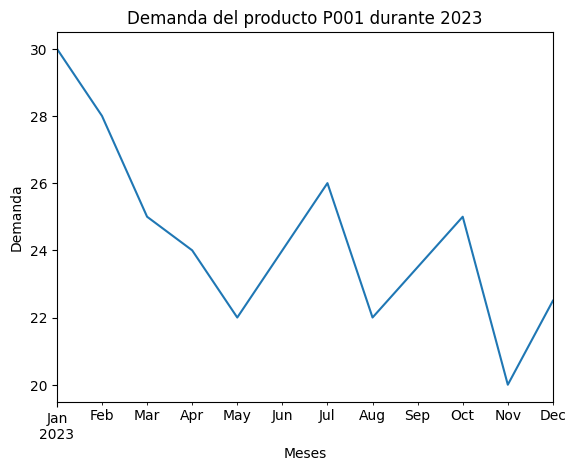

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,0
2024-01-01,22
2024-02-01,22
2024-03-01,21


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import Holt, SimpleExpSmoothing
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error
df_producto_P001=df.loc[df["producto_id"]=="P001",] #Se crea el df para el producto P001
df_producto_P001 = df_producto_P001.rename(columns={"unidades_vendidas": "Demanda"}) #Cambiamos el nombre de unidades vendidas a demanda para reflejar de mejor manera la demanda real y no solo las unidades vend
df_producto_P001
df_producto_P001 = df_producto_P001.set_index("fecha") #fijamos la fecha como el indice
df_producto_P001.loc[df_producto_P001["Demanda"] == 10, "Demanda"] = (22+26)/2 #proyectamos la demanda para junio (la proyectamos porque hubo quiebre de stock, la proyectamos como el promedio de la demanda del mes anterior y el siguiente en donde no hay quiebre de stock)
df_producto_P001.loc[df_producto_P001["Demanda"] == 8, "Demanda"] = (22+25)/2 #proyectamos la demanda para junio (la proyectamos porque hubo quiebre de stock, la proyectamos como el promedio de la demanda del mes anterior y el siguiente en donde no hay quiebre de stock)
df_producto_P001.loc[df_producto_P001["Demanda"] == 5, "Demanda"] = (20+25)/2 #proyectamos la demanda para junio (la proyectamos porque hubo quiebre de stock, la proyectamos como el promedio de la demanda del mes anterior y el siguiente en donde no hay quiebre de stock)
df_producto_P001_entrenamiento = df_producto_P001.iloc[0:9]
df_producto_P001_test = df_producto_P001.iloc[9:]
modelo_P001_entrenamiento = Holt(df_producto_P001_entrenamiento["Demanda"], exponential = False) #entrenamos el modelo con los 9 primeros registros del df
modelo_P001_entrenamiento_parametros = modelo_P001_entrenamiento.fit() #buscamos los parametros optimos para el modelo de entrenamiento
prediccion_P001 = modelo_P001_entrenamiento_parametros.forecast(3) #se pronostica la demanda para los 3 siguientes periodos para ver si es buen predictor el modelo
prediccion_P001 = prediccion_P001.round().astype(int)
mape_P001 = mean_absolute_percentage_error(df_producto_P001_test["Demanda"], prediccion_P001) #se calcula MAPE
mae_P001 = mean_absolute_error(df_producto_P001_test["Demanda"], prediccion_P001) #se calcula MAE
RMSE_P001 = mean_squared_error(df_producto_P001_test["Demanda"], prediccion_P001) ** 0.5 #se calcula RMSE
bias_P001 = (prediccion_P001 - df_producto_P001_test["Demanda"]).mean() #se calcula bias
plt.figure()
df_producto_P001["Demanda"].plot() #graficamos la demanda
plt.title("Demanda del producto P001 durante 2023")
plt.xlabel("Meses")
plt.ylabel("Demanda")
plt.show()

modelo_P001 = Holt(df_producto_P001["Demanda"], exponential = False) #ya que tenemos pocas observaciones y hay tendencia aplicamos holt
modelo_parametros_P001 = modelo_P001.fit() #buscamos los parametros de decision optimos
modelo_parametros_P001.params #visualizamos los parametros
forecast = modelo_parametros_P001.forecast(3) #proyectamos los 3 siguientes periodos
forecast_P001 = forecast.round().astype(int) #redondeamos
forecast_P001

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


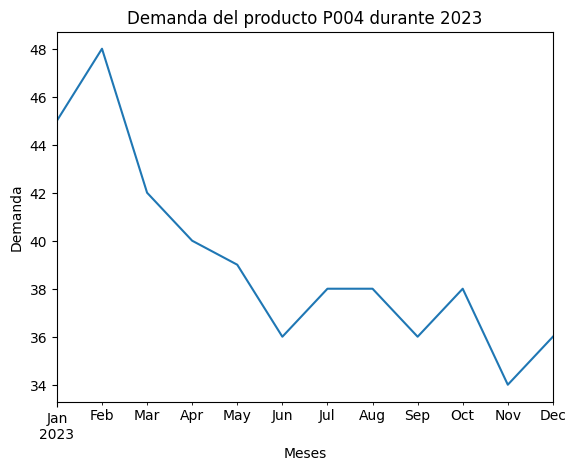

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,0
2024-01-01,35
2024-02-01,35
2024-03-01,34


In [ ]:
df_producto_P004 = df.loc[df["producto_id"] == "P004",] #Se crea el df para el producto P004
df_producto_P004 = df_producto_P004.rename(columns = {"unidades_vendidas": "Demanda"}) #Cambiamos el nombre de unidades vendidas a demanda para reflejar de mejor manera la demanda real y no solo las unidades vendidas
df_producto_P004.loc[df_producto_P004["Demanda"] == 12, "Demanda"] = (34+38)/2 #proyectamos la demanda para diciembre (hubo quiebre de stock, se proyecta como el promedio de los dos meses anteriores sin quiebre)
df_producto_P004 = df_producto_P004.set_index("fecha") #fijamos la fecha como el indice

df_producto_P004_entrenamiento = df_producto_P004.iloc[:9]
df_producto_P004_test = df_producto_P004.iloc[9:]
modelo_P004_entrenamiento = Holt(df_producto_P004_entrenamiento["Demanda"], exponential = False)
modelo_P004_entrenamiento_parametros = modelo_P004_entrenamiento.fit() #encontramos los parametros
prediccion_P004 = modelo_P004_entrenamiento_parametros.forecast(3).round().astype(int) #Hacemos la prediccion para los meses 10, 11 y 12
mape_P004 = mean_absolute_percentage_error(df_producto_P004_test["Demanda"], prediccion_P004) #Calculamos el MAPE
mae_P004 = mean_absolute_error(df_producto_P004_test["Demanda"], prediccion_P004) #Calculamos el mae
rmse_P004 = mean_squared_error(df_producto_P004_test["Demanda"], prediccion_P004) ** 0.5 #Calculamos RMSE
bias_P004 = (prediccion_P004 - df_producto_P004_test["Demanda"]).mean() #Calculamos el sesgo


plt.figure()
df_producto_P004["Demanda"].plot()
plt.title("Demanda del producto P004 durante 2023")
plt.xlabel("Meses")
plt.ylabel("Demanda")
plt.show()
modelo_P004 = Holt(df_producto_P004["Demanda"], exponential = False) #ya que hay tendencia descendente aplicamos Holt con tendencia aditiva
modelo_P004_parametros = modelo_P004.fit() #buscamos los parametros optimos
forecast_P004 = modelo_P004_parametros.forecast(3).round().astype(int) #proyectamos los 3 siguientes periodos y redondeamos
forecast_P004

/tmp/ipykernel_994/2661902025.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '18.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_producto_P002.loc[df_producto_P002["fecha"] == "2023-06-01", "Demanda"] = (15+22)/2 #proyectamos la demanda para junio (hubo quiebre de stock, se proyecta como el promedio del mes anterior y siguiente sin quiebre)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


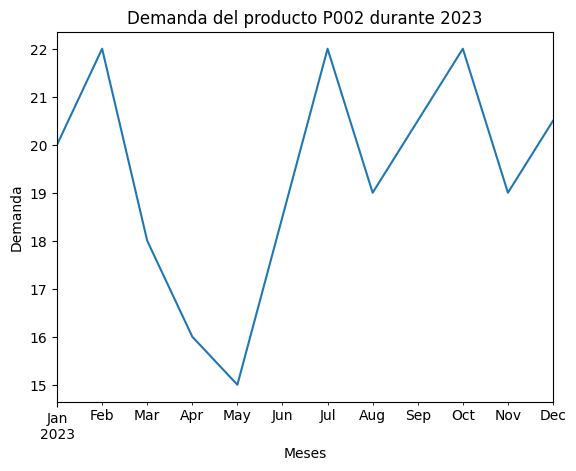

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,0
2024-01-01,20
2024-02-01,20
2024-03-01,20


In [ ]:
df_producto_P002 = df.loc[df["producto_id"] == "P002",] #Se crea el df para el producto P002
df_producto_P002 = df_producto_P002.rename(columns = {"unidades_vendidas": "Demanda"}) #Cambiamos el nombre de unidades vendidas a demanda para reflejar de mejor manera la demanda real y no solo las unidades vendidas
df_producto_P002.loc[df_producto_P002["fecha"] == "2023-06-01", "Demanda"] = (15+22)/2 #proyectamos la demanda para junio (hubo quiebre de stock, se proyecta como el promedio del mes anterior y siguiente sin quiebre)
df_producto_P002.loc[df_producto_P002["fecha"] == "2023-09-01", "Demanda"] = (19+22)/2 #proyectamos la demanda para septiembre (hubo quiebre de stock, se proyecta como el promedio del mes anterior y siguiente sin quiebre)
df_producto_P002.loc[df_producto_P002["fecha"] == "2023-12-01", "Demanda"] = (19+22)/2 #proyectamos la demanda para diciembre (hubo quiebre de stock, se proyecta como el promedio de los dos meses anteriores sin quiebre)
df_producto_P002 = df_producto_P002.set_index("fecha") #fijamos la fecha como el indice
df_producto_P002_entrenamiento = df_producto_P002.iloc[:9] #creamos el df de entrenamiento
df_producto_P002_test = df_producto_P002.iloc[9:] #creamos el df de prueba
modelo_P002_entrenamiento = SimpleExpSmoothing(df_producto_P002_entrenamiento["Demanda"]) #Entrenamos el modelo en base al df de entrenamiento
modelo_P002_entrenamiento_parametros = modelo_P002_entrenamiento.fit() #Buscamos los parametros optimos
prediccion_P002 = modelo_P002_entrenamiento_parametros.forecast(3).round().astype(int) #hacemos la prediccion para los meses 10, 11 y 12
mape_P002 = mean_absolute_percentage_error(df_producto_P002_test["Demanda"], prediccion_P002) #Calculamos MAPE
mae_P002 = mean_absolute_error(df_producto_P002_test["Demanda"], prediccion_P002) #Calculamos el MAE
rmse_P002 = mean_squared_error(df_producto_P002_test["Demanda"], prediccion_P002) ** 0.5 #Calculamos RMSE
bias_P002 = (prediccion_P002 - df_producto_P002_test["Demanda"]).mean() #Calculamos el sesgo
plt.figure()
df_producto_P002["Demanda"].plot()
plt.title("Demanda del producto P002 durante 2023")
plt.xlabel("Meses")
plt.ylabel("Demanda")
plt.show()
modelo_P002 = SimpleExpSmoothing(df_producto_P002["Demanda"]) #ya que no hay tendencia ni estacionalidad clara aplicamos SES
modelo_P002_parametros = modelo_P002.fit() #buscamos los parametros optimos
modelo_P002_parametros.params #visualizamos los parametros del modelo
forecast_P002 = modelo_P002_parametros.forecast(3).round().astype(int) #proyectamos los 3 siguientes periodos y redondeamos
forecast_P002

In [ ]:
resumen = pd.DataFrame({
    'Producto' : ['P001', 'P002', 'P004'],
    'Modelo'   : ['Holt', 'SES', 'Holt'],
    'MAPE'     : [mape_P001, mape_P002, mape_P004],
    'MAE'      : [mae_P001, mae_P002, mae_P004],
    'RMSE'     : [RMSE_P001, rmse_P002, rmse_P004],
    'Bias'     : [bias_P001, bias_P002, bias_P004]
})


resumen = resumen.set_index("Producto")
display(resumen)

,Modelo,MAPE,MAE,RMSE,Bias
Producto,,,,,
P001,Holt,0.0841,1.8333,2.1016,0.1667
P002,SES,0.0560,1.1667,1.3229,-0.5000
P004,Holt,0.0459,1.6667,1.7321,-1.0000


In [ ]:
tabla_forecast_producto = pd.DataFrame({
    "producto_id": ["P001", "P002", "P004"],
    "Demanda_pronosticada": [
        forecast_P001.sum(),
        forecast_P002.sum(),
        forecast_P004.sum()
    ]
})

display(tabla_forecast_producto)

,producto_id,Demanda_pronosticada
0,P001,65
1,P002,60
2,P004,104


In [ ]:
ultima_fecha = df_inventarios["fecha"].max() #Obtenemos la ultima fecha de registro de inventario
inventario_ultimo_mes = df_inventarios.loc[(df_inventarios["fecha"] == ultima_fecha) & (df_inventarios["producto_id"].isin(["P001","P002","P004" ])) , ["producto_id", "producto_nombre", "inventario_final"]]


tabla_combinada_inventario_final_pronostico = inventario_ultimo_mes.merge(tabla_forecast_producto, on = "producto_id", how = "inner")
tabla_combinada_inventario_final_pronostico["Cantidad_pedido"] = tabla_combinada_inventario_final_pronostico["Demanda_pronosticada"] - tabla_combinada_inventario_final_pronostico["inventario_final"]
display(tabla_combinada_inventario_final_pronostico)

,producto_id,producto_nombre,inventario_final,Demanda_pronosticada,Cantidad_pedido
0,P001,Laptop ProBook,0,65,65
1,P002,"Monitor 24""",0,60,60
2,P004,Mouse Optico,0,104,104


In [ ]:
resumen_forecast = pd.DataFrame({"Periodo": ["Enero 2024", "Febrero 2024", "Marzo 2024"], "P001": forecast_P001.values, "P002": forecast_P002.values, "P004": forecast_P004.values})
display(resumen_forecast)

,Periodo,P001,P002,P004
0,Enero 2024,22,20,35
1,Febrero 2024,22,20,35
2,Marzo 2024,21,20,34


In [ ]:
resumen_forecast.to_csv("resumen_prediccion_proyecto.csv", index = False)
tabla_combinada_inventario_final_pronostico.to_csv("tabla_combinada_inventario_final_pronostico.csv", index = False)
resumen.to_csv("Resumen_metricas_prediccion.csv", index = False)